# Compact Finite Difference Derivatives in Python

This notebook demonstrates the implementation of compact finite difference
schemes for numerical differentiation in one dimension.

The goal is to reproduce the MATLAB example used in our work and gradually
build a reusable Python class that constructs the differentiation matrices
once and can then be used to compute derivatives of many fields efficiently.

The implementation follows the methodology used in 

"High-Order Compact Finite Difference Methods: Theory, Implementation and Applications" by Arroyo-Ramo, Pérez-Quiles and Hoyas

## Import libraries

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import compactFD

importlib.reload(compactFD)
from compactFD import CompactFD



Domain discretization


In [135]:
#x = np.linspace(-1,1,101)
#fd = CompactFD(x)

#fd = CompactFD(n=201,a=-1,b=1,mesh="tanh")

fd = CompactFD(n=201,a=-1,b=1,mesh="tanh",u1d=5,du1d=5,u2d=7,du2d=7)

fd.build_first_derivative()
fd.build_second_derivative()


# Check the first derivative

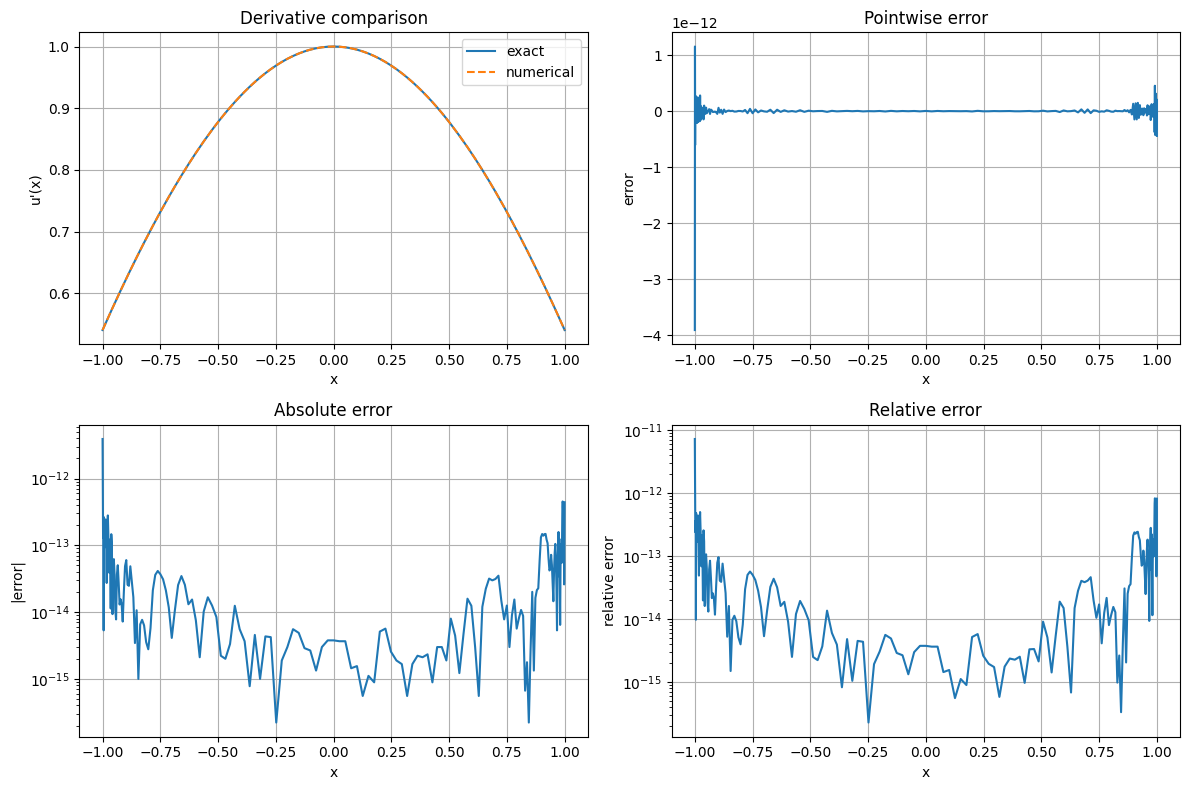

In [136]:
f = np.sin(fd.x)

ux = fd.dx(f)
ux_exact = np.cos(fd.x)

error = ux - ux_exact
abs_error = np.abs(error)
rel_error = abs_error / np.maximum(np.abs(ux_exact),1e-14)

fig,axs = plt.subplots(2,2,figsize=(12,8))

# 1. exact vs numerical
axs[0,0].plot(fd.x,ux_exact,label="exact")
axs[0,0].plot(fd.x,ux,'--',label="numerical")
axs[0,0].set_title("Derivative comparison")
axs[0,0].set_xlabel("x")
axs[0,0].set_ylabel("u'(x)")
axs[0,0].legend()
axs[0,0].grid()

# 2. pointwise error
axs[0,1].plot(fd.x,error)
axs[0,1].set_title("Pointwise error")
axs[0,1].set_xlabel("x")
axs[0,1].set_ylabel("error")
axs[0,1].grid()

# 3. absolute error
axs[1,0].semilogy(fd.x,abs_error)
axs[1,0].set_title("Absolute error")
axs[1,0].set_xlabel("x")
axs[1,0].set_ylabel("|error|")
axs[1,0].grid()

# 4. relative error
axs[1,1].semilogy(fd.x,rel_error)
axs[1,1].set_title("Relative error")
axs[1,1].set_xlabel("x")
axs[1,1].set_ylabel("relative error")
axs[1,1].grid()

plt.tight_layout()
plt.show()

# Check the second derivative. 

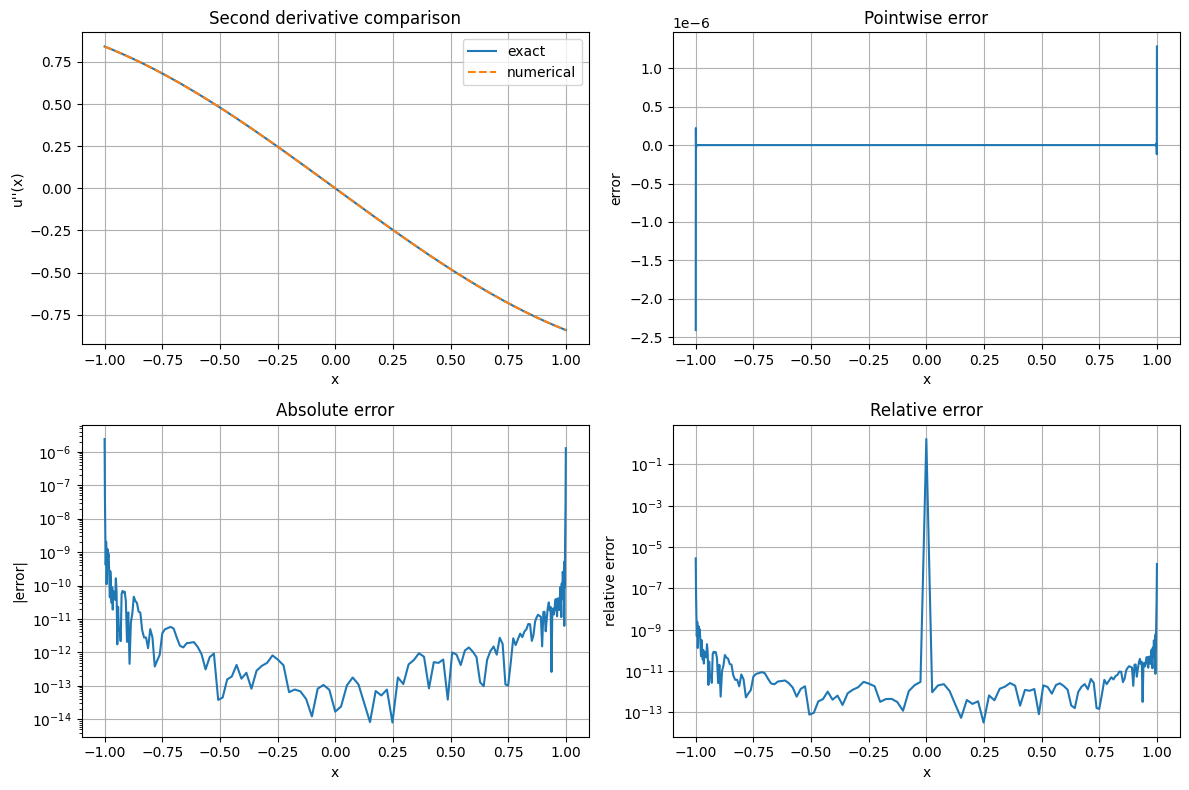

In [137]:
f = np.sin(fd.x)

uxx = fd.dxx(f)
uxx_exact = -np.sin(fd.x)

error = uxx - uxx_exact
abs_error = np.abs(error)
rel_error = abs_error / np.maximum(np.abs(uxx_exact),1e-14)

fig,axs = plt.subplots(2,2,figsize=(12,8))

# 1. exact vs numerical
axs[0,0].plot(fd.x,uxx_exact,label="exact")
axs[0,0].plot(fd.x,uxx,'--',label="numerical")
axs[0,0].set_title("Second derivative comparison")
axs[0,0].set_xlabel("x")
axs[0,0].set_ylabel("u''(x)")
axs[0,0].legend()
axs[0,0].grid()

# 2. pointwise error
axs[0,1].plot(fd.x,error)
axs[0,1].set_title("Pointwise error")
axs[0,1].set_xlabel("x")
axs[0,1].set_ylabel("error")
axs[0,1].grid()

# 3. absolute error
axs[1,0].semilogy(fd.x,abs_error)
axs[1,0].set_title("Absolute error")
axs[1,0].set_xlabel("x")
axs[1,0].set_ylabel("|error|")
axs[1,0].grid()

# 4. relative error
axs[1,1].semilogy(fd.x,rel_error)
axs[1,1].set_title("Relative error")
axs[1,1].set_xlabel("x")
axs[1,1].set_ylabel("relative error")
axs[1,1].grid()

plt.tight_layout()
plt.show()

# L_2 convergence


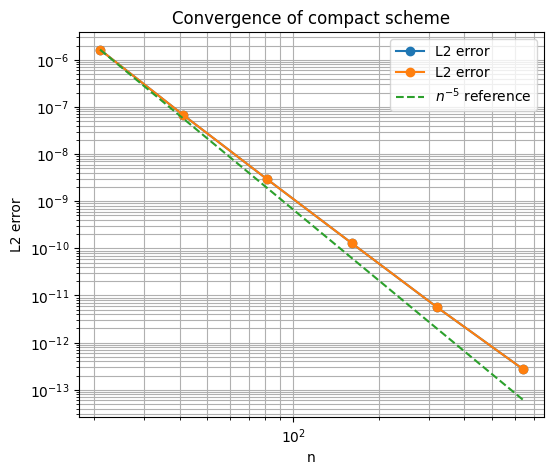

In [138]:
n_values = [21,41,81,161,321,641]

L2 = []
a = -1
b =  1

for n in n_values:
    
    fd = CompactFD(n=n,a=a,b=b,mesh="uniform",u1d=5,du1d=5,u2d=7,du2d=7)
    
    fd.build_first_derivative()
    
    f = np.sin(fd.x)
    
    ux = fd.dx(f)
    ux_exact = np.cos(fd.x)
    
    error = ux - ux_exact
    
    L2.append(np.sqrt(np.mean(error**2)))

L2 = np.array(L2)

plt.figure(figsize=(6,5))

plt.loglog(n_values,L2,'o-',label="L2 error")


p = 5
ref = L2[0]*(np.array(n_values)/n_values[0])**(-p)

plt.loglog(n_values,L2,'o-',label="L2 error")
plt.loglog(n_values,ref,'--',label=f"$n^{{-{p}}}$ reference")

plt.xlabel("n")
plt.ylabel("L2 error")
plt.title("Convergence of compact scheme")
plt.grid(True,which="both")
plt.legend()
plt.show()

Convergence

Observed order from Fourier test: 5.003310750825937


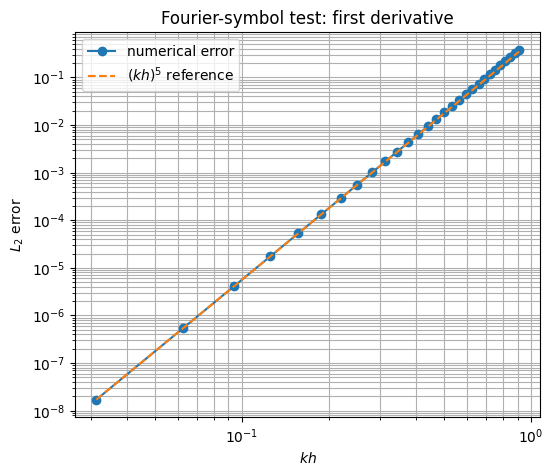

In [139]:
import numpy as np
import matplotlib.pyplot as plt

# malla uniforme
fd = CompactFD(n=201, a=-1, b=1, mesh="uniform",u1d=3,du1d=5,u2d=7,du2d=7)
fd.build_first_derivative()

# operador explícito
D = np.linalg.solve(fd.Ax, fd.Bx)

x = fd.x
h = x[1] - x[0]
L = x[-1] - x[0]

# números de onda discretos
modes = np.arange(1, 30)
kh_vals = []
err_vals = []

for m in modes:
    k = 2*np.pi*m / L
    f = np.exp(1j * k * x)

    df_num = D @ f
    df_ex = 1j * k * f

    # error interior para evitar contaminación de frontera
    sl = slice(20, -20)
    err = np.sqrt(np.mean(np.abs(df_num[sl] - df_ex[sl])**2))

    kh_vals.append(k * h)
    err_vals.append(err)

kh_vals = np.array(kh_vals)
err_vals = np.array(err_vals)
import numpy as np
import matplotlib.pyplot as plt

# malla uniforme
fd = CompactFD(n=201, a=-1, b=1, mesh="uniform")
fd.build_first_derivative()

# operador explícito
D = np.linalg.solve(fd.Ax, fd.Bx)

x = fd.x
h = x[1] - x[0]
L = x[-1] - x[0]

# números de onda discretos
modes = np.arange(1, 30)
kh_vals = []
err_vals = []

for m in modes:
    k = 2*np.pi*m / L
    f = np.exp(1j * k * x)

    df_num = D @ f
    df_ex = 1j * k * f

    # error interior para evitar contaminación de frontera
    sl = slice(20, -20)
    err = np.sqrt(np.mean(np.abs(df_num[sl] - df_ex[sl])**2))

    kh_vals.append(k * h)
    err_vals.append(err)

kh_vals = np.array(kh_vals)
err_vals = np.array(err_vals)

nfit = 8

coef = np.polyfit(np.log(kh_vals[:nfit]), np.log(err_vals[:nfit]), 1)

p_obs = coef[0]

print("Observed order from Fourier test:", p_obs)
pref = 5
ref = err_vals[0] * (kh_vals / kh_vals[0])**pref


plt.figure(figsize=(6,5))
plt.loglog(kh_vals, err_vals, 'o-', label='numerical error')
plt.loglog(kh_vals, ref, '--', label=fr'$(kh)^{{{pref}}}$ reference')
plt.xlabel(r'$kh$')
plt.ylabel(r'$L_2$ error')
plt.title('Fourier-symbol test: first derivative')
plt.grid(True, which='both')
plt.legend()
plt.show()

# all central ponts 

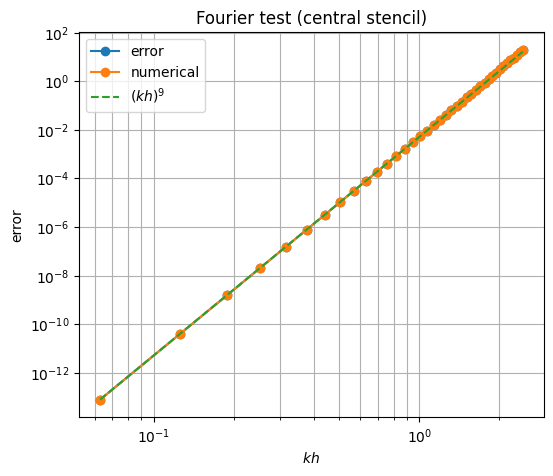

Observed order: 8.99687736312276
[7.82079591e-14 3.96198630e-11 1.52360613e-09 2.02956905e-08
 1.51255055e-07 7.80712558e-07 3.12753194e-06 1.04079319e-05
 3.00625114e-05 7.76590551e-05]


In [140]:
import numpy as np
import matplotlib.pyplot as plt

u1d=3
du1d=7

p = u1d+du1d-1

fd = CompactFD(n=101, a=-1, b=1, mesh="uniform",u1d=u1d,du1d=du1d,u2d=7,du2d=7)

fd.build_first_derivative()

# operador global
D = np.linalg.solve(fd.Ax, fd.Bx)

x = fd.x
h = x[1] - x[0]
L = x[-1] - x[0]

# punto central
i0 = len(x)//2

modes = np.arange(1,40)

kh_vals = []
err_vals = []

for m in modes:

    k = 2*np.pi*m/L

    f = np.exp(1j*k*x)

    df_num = D @ f
    df_ex  = 1j*k*f

    err = np.abs(df_num[i0] - df_ex[i0])

    kh_vals.append(k*h)
    err_vals.append(err)

kh_vals = np.array(kh_vals)
err_vals = np.array(err_vals)

plt.figure(figsize=(6,5))

plt.loglog(kh_vals,err_vals,'o-',label="error")

plt.xlabel(r"$kh$")
plt.ylabel("error at center")
plt.title("Fourier symbol test (central point)")
plt.grid(True,which="both")
plt.legend()

# p = 5

ref = err_vals[0]*(kh_vals/kh_vals[0])**p

plt.loglog(kh_vals,err_vals,'o-',label="numerical")
plt.loglog(kh_vals, ref, '--', label=rf"$(kh)^{{{p}}}$")
plt.xlabel(r"$kh$")
plt.ylabel("error")
plt.title("Fourier test (central stencil)")
plt.grid(True,which="both")
plt.legend()

plt.show()



nfit = 8

coef = np.polyfit(np.log(kh_vals[:nfit]), np.log(err_vals[:nfit]),1)

print("Observed order:",coef[0])
print(err_vals[:10])


# Integration

In [154]:
def test_function(x, case="sin1"):
    """
    Return (usol, f) such that -u'' = f.

    Parameters
    ----------
    x : ndarray
        Grid
    case : str
        Test function identifier

    Returns
    -------
    usol : ndarray
    f : ndarray
    """

    match case:

        case "sin1":
            usol = np.sin(x)
            f = np.sin(x)

        case "sin5":
            usol = np.sin(5*x)
            f = 25*np.sin(5*x)

        case "sin10":
            usol = np.sin(10*x)
            f = 100*np.sin(10*x)

        case "poly4":
            usol = x**4
            f = -12*x**2

        case "mixed":
            usol = x**2*np.sin(3*x)
            f = (
                -2*np.sin(3*x)
                -12*x*np.cos(3*x)
                +9*x**2*np.sin(3*x)
            )

        case "multisine":
            usol = np.sin(x) + 0.5*np.sin(3*x) + 0.25*np.sin(5*x)
            f = (
                np.sin(x)
                +4.5*np.sin(3*x)
                +6.25*np.sin(5*x)
            )

        case "exp":
            usol = np.exp(x)
            f = -np.exp(x)

        case _:
            raise ValueError(f"Unknown test function: {case}")

    return usol, f

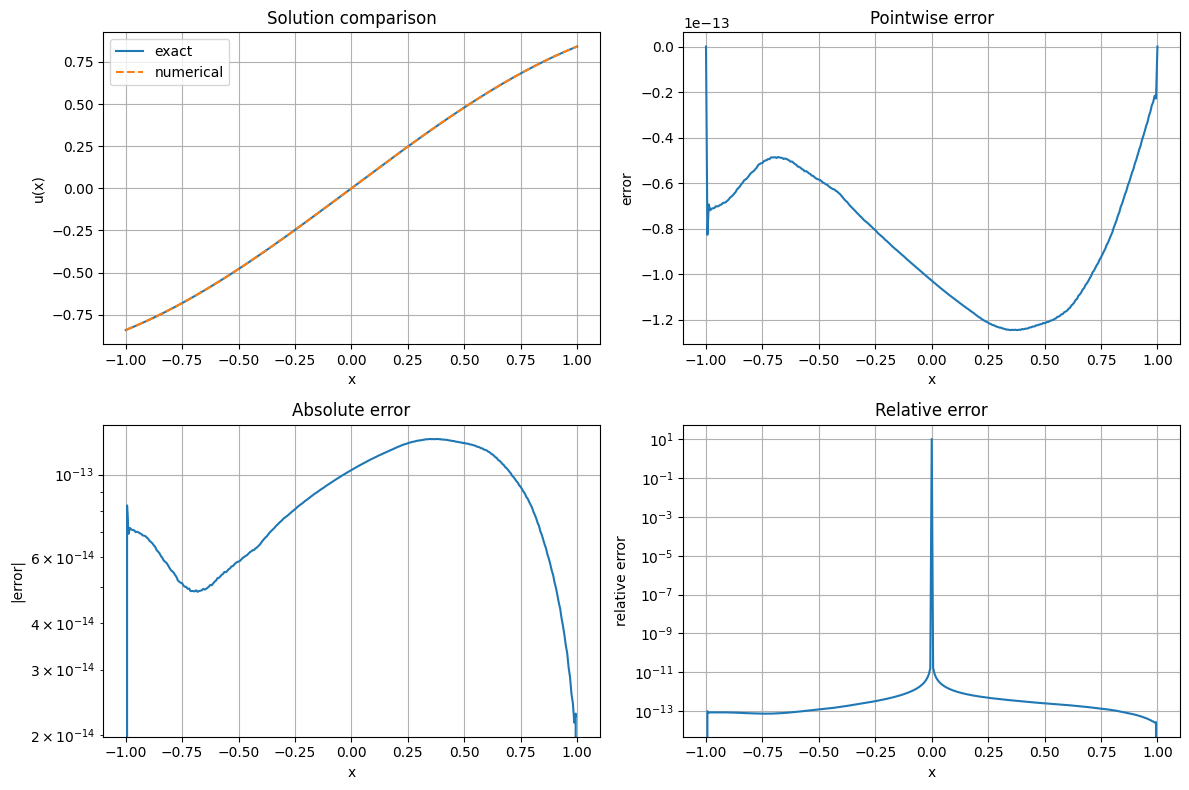

In [155]:
f,usol = test_function(x, case="sin1")
CC1 = usol[0]
CC2 = usol[-1]

fd.build_second_derivative()
u = fd.solve_dirichlet(f, CC1, CC2)

error = u - usol
abs_error = np.abs(error)
rel_error = abs_error / np.maximum(np.abs(usol),1e-14)

fig,axs = plt.subplots(2,2,figsize=(12,8))

# 1. exact vs numerical
axs[0,0].plot(x,usol,label="exact")
axs[0,0].plot(x,u,'--',label="numerical")
axs[0,0].set_title("Solution comparison")
axs[0,0].set_xlabel("x")
axs[0,0].set_ylabel("u(x)")
axs[0,0].legend()
axs[0,0].grid()

# 2. pointwise error
axs[0,1].plot(x,error)
axs[0,1].set_title("Pointwise error")
axs[0,1].set_xlabel("x")
axs[0,1].set_ylabel("error")
axs[0,1].grid()

# 3. absolute error
axs[1,0].semilogy(x,abs_error)
axs[1,0].set_title("Absolute error")
axs[1,0].set_xlabel("x")
axs[1,0].set_ylabel("|error|")
axs[1,0].grid()

# 4. relative error
axs[1,1].semilogy(x,rel_error)
axs[1,1].set_title("Relative error")
axs[1,1].set_xlabel("x")
axs[1,1].set_ylabel("relative error")
axs[1,1].grid()

plt.tight_layout()
plt.show()

Observed order: 0.2656995258980934


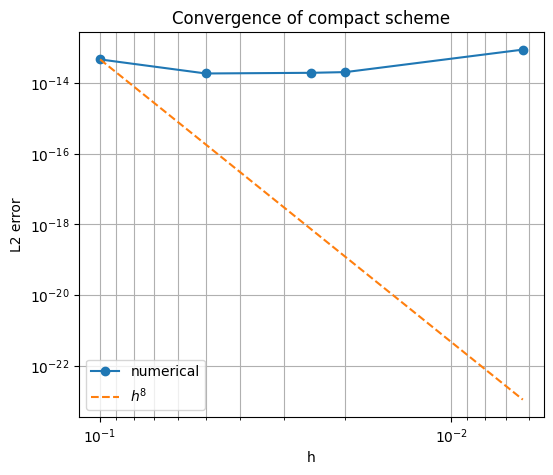

[4.72154547e-14 1.88831623e-14 1.97191987e-14 2.06562854e-14
 8.94330527e-14]


In [ ]:

n_values = [21, 41, 81, 101, 321]
L2_vals = []
h_vals = []

for n in n_values:
    fd = CompactFD(n=n, a=-1, b=1, mesh="uniform",u1d=3,du1d=5,u2d=7,du2d=7)
    fd.build_second_derivative()
    
    x = fd.x

    # Exact solution
    #  
    f,usol = test_function(x, case="multisine")

    CC1 = usol[0]
    CC2 = usol[-1]
    
    u = fd.solve_dirichlet(f, CC1, CC2)
    
    error = u - usol
    
    L2 = np.sqrt(np.mean(error**2))
    
    L2_vals.append(L2)
    
    h = (x[-1]-x[0])/(len(x)-1)
    h_vals.append(h)

L2_vals = np.array(L2_vals)
h_vals = np.array(h_vals)

# orden observado
coef = np.polyfit(np.log(h_vals), np.log(L2_vals), 1)
p_obs = -coef[0]

print("Observed order:", p_obs)

# referencia teórica
p = 8
ref = L2_vals[0]*(h_vals/h_vals[0])**p

plt.figure(figsize=(6,5))

plt.loglog(h_vals, L2_vals, 'o-', label="numerical")
plt.loglog(h_vals, ref, '--', label=rf"$h^{{{p}}}$")

plt.gca().invert_xaxis()

plt.xlabel("h")
plt.ylabel("L2 error")
plt.title("Convergence of compact scheme")
plt.grid(True, which="both")
plt.legend()

plt.show()

print(L2_vals)
